# ARI5121 – Applied NLP | Speech Analysis and Evaluation Project

## 0. Setup

In [1]:
import time

# File handling
import os
import shutil
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd
from itertools import combinations

# Audio loading
import librosa

# Deep learning / Hugging Face
import torch
import torch.nn.functional as F
from transformers import AutoFeatureExtractor, AutoModelForAudioXVector

# Evaluation and visualisation
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

/home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 0.1. Config Parameters

In [2]:
MODEL_NAME = "microsoft/wavlm-base-plus-sv"
TARGET_SAMPLE_RATE = 16000

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f">> [OK] Device Selected: {DEVICE}")

CORPUS_DIR = Path("../ABI-1 Corpus")
OUTPUT_DIR = Path("../extracted_wavs")
RESULTS_DIR = Path("../results")

>> [OK] Device Selected: cuda


### 0.2. Execution Timer

In [19]:
start_time = time.time()

## 1. Validate Corpus Existance

In [4]:
# validate corpus
def validate_corpus_folder(corpus_dir):
    """
    Checks that the ABI-1 corpus folder exists inside the project directory.
    """

    if not corpus_dir.exists():
        raise FileNotFoundError(
            f">> [ERROR] Corpus folder not found.\n"
            f"Expected location:\n{corpus_dir.resolve()}\n\n"
            f"Make sure the ABI-1 corpus folder is inside your project directory."
        )

    if not corpus_dir.is_dir():
        raise NotADirectoryError(
            f">> [ERROR] Corpus path exists, but it is not a folder:\n{corpus_dir.resolve()}"
        )

    print(f">> [OK] Corpus folder found: {corpus_dir.resolve()}")

In [5]:
validate_corpus_folder(CORPUS_DIR)

>> [OK] Corpus folder found: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/ABI-1 Corpus


## 2. Extract shortpassage WAV files

In [6]:
def extract_shortpassage_waves(corpus_dir, output_dir):
    """
    Copies only the required shortpassage .wav files into a cleaned folder.
    """
    
    # create output dir if it doesn't exits
    output_dir.mkdir(parents=True, exist_ok=True)
    
    copied_count = 0
    skipped_count = 0
    
    for root, _, files in os.walk(corpus_dir):
        root_path = Path(root)
        
        for file_name in files:
            file_path = root_path / file_name
            
            # Check is a file is a .wav file and has shortpassage in the name
            is_wav = file_path.suffix.lower() == ".wav"
            is_shortpassage = "shortpassage" in file_name.lower()
            
            if not is_wav or not is_shortpassage:
                skipped_count += 1
                continue
            
            # Get path relative to the original corpus folder
            relative_path = file_path.relative_to(corpus_dir)

            # Copy into cleaned folder while preserving folder structure
            destination_path = output_dir / relative_path

            # Create destination parent folders
            destination_path.parent.mkdir(parents=True, exist_ok=True)

            # Copy file
            shutil.copy2(file_path, destination_path)

            copied_count += 1
            # print(f">> [COPIED] {relative_path}")

    print(">> --- [CLEANING COMPLETE] --- :")
    print(f">> WAV files copied: {copied_count}")
    print(f">> Files skipped: {skipped_count}")
    print(f">> Cleaned folder: {output_dir.resolve()}")

In [7]:
extract_shortpassage_waves(CORPUS_DIR, OUTPUT_DIR)

>> --- [CLEANING COMPLETE] --- :
>> WAV files copied: 855
>> Files skipped: 7702
>> Cleaned folder: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/extracted_wavs


## 3. Create a metadata CSV

In [8]:
def create_metadata(cleaned_dir):
    """
    Creates a metadata CSV from the cleaned WAV folder.
    """

    records = []

    for wav_path in cleaned_dir.rglob("*.wav"):
        relative_parts = wav_path.relative_to(cleaned_dir).parts
        # print(relative_parts)     # Structure is ('accents', 'crn_001', 'female', 'lms002', 'shortpassagea_CT.wav')

        if len(relative_parts) < 5:
            print(f">> [WARNING] Unexpected path structure: {relative_parts}")
            continue

        accent = relative_parts[1]
        gender = relative_parts[2]
        speaker_id = relative_parts[3]

        records.append({
            "accent": accent,
            "gender": gender,
            "speaker_id": speaker_id,
            "file_path": str(wav_path.resolve())
        })

    metadata_df = pd.DataFrame(records)

    output_path = cleaned_dir / "metadata.csv"
    metadata_df.to_csv(output_path, index=False)

    print(f">> [OK] Metadata created: {output_path.resolve()}")
    print(f">> [INFO] Number of WAV files: {len(metadata_df)}")
    print(f">> [INFO] Number of speakers: {metadata_df['speaker_id'].nunique()}")

    return metadata_df

In [9]:
metadata_df = create_metadata(OUTPUT_DIR)

>> [OK] Metadata created: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/extracted_wavs/metadata.csv
>> [INFO] Number of WAV files: 855
>> [INFO] Number of speakers: 284


## 4. Load WavLM

In [3]:
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)    # Load the feature extractor for the WavLM-sv model.
model = AutoModelForAudioXVector.from_pretrained(MODEL_NAME)            # Load the pre-trained WavLM-sv model.

model = model.to(DEVICE)
model.eval()

print(f">> [OK] Model loaded: {MODEL_NAME}")
print(f">> [INFO] Device: {DEVICE}")

Loading weights: 100%|██████████| 266/266 [00:00<00:00, 18628.90it/s]


>> [OK] Model loaded: microsoft/wavlm-base-plus-sv
>> [INFO] Device: cuda


## 5. Extract Speaker Embeddings

In [11]:
def extract_embedding(file_path):
    """
    Loads a WAV file and extracts a speaker embedding using WavLM.
    """
    
    # Load and resample audio to 16 kHz.
    audio, sample_rate = librosa.load(file_path, sr=TARGET_SAMPLE_RATE, mono=True)

    # Prepare audio for the model.
    inputs = feature_extractor(audio, sampling_rate=sample_rate, return_tensors="pt", padding=True)

    # Move inputs to selected device.
    inputs = {key: value.to(DEVICE) for key, value in inputs.items()}

    # Extract embedding without calculating gradients.
    with torch.no_grad():
        outputs = model(**inputs)

    # Extract the single embedding vector and move it back to CPU.
    embedding = outputs.embeddings[0].cpu()

    return embedding

In [ ]:
embedding_records = []
failed_files = []

for index, row in metadata_df.iterrows():
    file_path = row["file_path"]

    try:
        embedding = extract_embedding(file_path)

        embedding_records.append({
            "accent": row["accent"],
            "gender": row["gender"],
            "speaker_id": row["speaker_id"],
            "file_path": file_path,
            "embedding": embedding.numpy()
        })

        print(f">> [OK] Extracted embedding {index + 1}/{len(metadata_df)}", end="\r", flush=True)

    except Exception as error:
        failed_files.append({
            "file_path": file_path,
            "error": str(error)
        })

        print(f">> [ERROR] Failed to extract embedding for: {file_path}")
        print(error)

embedding_df = pd.DataFrame(embedding_records)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
embedding_output_path = RESULTS_DIR / "speaker_embeddings.pkl"
embedding_df.to_pickle(embedding_output_path)

print(f">> [OK] Speaker embeddings saved to: {embedding_output_path.resolve()}")
print(f">> [INFO] Successful embeddings: {len(embedding_df)}")
print(f">> [INFO] Failed files: {len(failed_files)}")

/home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/.venv/lib/python3.12/site-packages/torch/nn/functional.py:6441: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


>> [OK] Speaker embeddings saved to: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/speaker_embeddings.pkl
>> [INFO] Successful embeddings: 855
>> [INFO] Failed files: 0


## 7. Pairwise Cosine Similarities

In [4]:
# Use saved pickle file
embedding_path = RESULTS_DIR / "speaker_embeddings.pkl"
embedding_df = pd.read_pickle(embedding_path)

similarity_records = []

# Calculate the total number of unique pairs - For n embeddings, the number of pairs is n * (n - 1) / 2
total_pairs = len(embedding_df) * (len(embedding_df) - 1) // 2

# Compare every unique pair of embeddings - combinations(..., 2) avoids comparing a file with itself and avoids duplicate comparisons
for pair_index, (idx1, idx2) in enumerate(combinations(embedding_df.index, 2), start=1):
    # Get the two rows being compared.
    row1 = embedding_df.loc[idx1]
    row2 = embedding_df.loc[idx2]

    # Convert the saved NumPy embeddings back into PyTorch tensors
    embedding_1 = torch.tensor(row1["embedding"])
    embedding_2 = torch.tensor(row2["embedding"])

    # Compute cosine similarity between the two speaker embeddings - high scores are better
    similarity = F.cosine_similarity(
        embedding_1,
        embedding_2,
        dim=0
    ).item()

    # Check if the two files belong to the same speaker - Ground-Truth label for comparison
    same_speaker = row1["speaker_id"] == row2["speaker_id"]

    # Store results
    similarity_records.append({
        "file_path_1": row1["file_path"],
        "file_path_2": row2["file_path"],
        "speaker_id_1": row1["speaker_id"],
        "speaker_id_2": row2["speaker_id"],
        "same_speaker": same_speaker,
        "cosine_similarity": similarity
    })

    print(f">> [INFO] Compared pair {pair_index}/{total_pairs}", end="\r", flush=True)

# Convert to DataFrame
similarity_df = pd.DataFrame(similarity_records)

# Save Results to a .pkl file
similarity_output_path = RESULTS_DIR / "pairwise_similarities.pkl"
similarity_df.to_pickle(similarity_output_path)

print(f"\n>> [OK] Pairwise similarities saved to: {similarity_output_path.resolve()}")
print(f">> [INFO] Total comparisons: {len(similarity_df)}")

>> [INFO] Compared pair 365085/365085
>> [OK] Pairwise similarities saved to: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/pairwise_similarities.pkl
>> [INFO] Total comparisons: 365085


## 8. Evaluate Cosine Similarity Thresholds

In [ ]:
threshold_results = []

# Thresholds to test.
thresholds = np.arange(0.50, 0.96, 0.05)

for threshold in thresholds:
    # Predict same speaker if cosine similarity is above the threshold.
    similarity_df["predicted_same_speaker"] = similarity_df["cosine_similarity"] >= threshold

    # True labels.
    y_true = similarity_df["same_speaker"]

    # Predicted labels.
    y_pred = similarity_df["predicted_same_speaker"]

    # Calculate accuracy.
    accuracy = accuracy_score(y_true, y_pred)

    # Calculate confusion matrix values.
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "true_positive": tp,
        "false_positive": fp,
        "false_negative": fn,
        "true_negative": tn
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_output_path = RESULTS_DIR / "threshold_results.csv"
threshold_results_df.to_csv(threshold_output_path, index=False)

print(f">> [OK] Threshold results saved to: {threshold_output_path.resolve()}")
threshold_results_df

>> [OK] Threshold results saved to: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/threshold_results.csv


,threshold,accuracy,true_positive,false_positive,false_negative,true_negative
0,0.50,0.044318,864,348905,0,15316
1,0.55,0.089848,864,332283,0,31938
2,0.60,0.154939,864,308519,0,55702
3,0.65,0.238796,864,277904,0,86317
4,0.70,0.340354,864,240827,0,123394
5,0.75,0.457178,856,198168,8,166053
6,0.80,0.592602,855,148726,9,215495
7,0.85,0.738518,855,95454,9,268767
8,0.90,0.882312,855,42957,9,321264
9,0.95,0.985836,855,5162,9,359059


In [11]:
best_result = threshold_results_df.sort_values(
    by="accuracy",
    ascending=False
).iloc[0]

best_threshold = best_result["threshold"]

print(f">> [OK] Best threshold: {best_threshold:.2f}")
print(f">> [INFO] Best accuracy: {best_result['accuracy']:.3f}")

>> [OK] Best threshold: 0.95
>> [INFO] Best accuracy: 0.986


## 9. Confusion Matrix

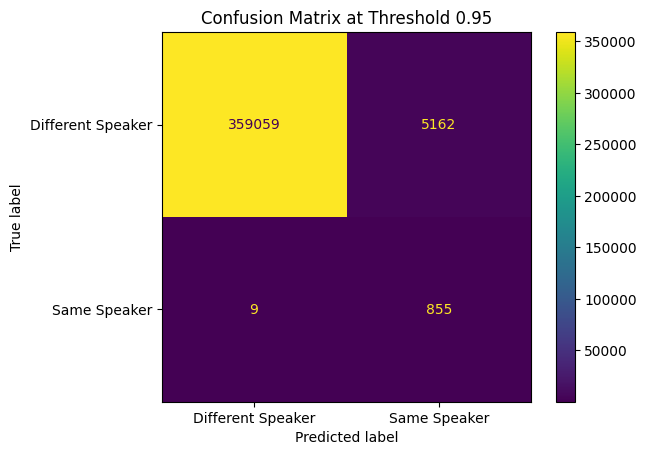

>> [OK] Confusion matrix saved to: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/confusion_matrix.png


In [41]:
# True labels.
y_true = similarity_df["same_speaker"]

# Predicted labels using the best threshold.
y_pred = similarity_df["cosine_similarity"] >= best_threshold

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Different Speaker", "Same Speaker"]
)

disp.plot()

plt.title(f"Confusion Matrix at Threshold {best_threshold:.2f}")

cm_path = RESULTS_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")

plt.show()

print(f">> [OK] Confusion matrix saved to: {cm_path.resolve()}")

### 9.1 Normalised Confusion Matrix

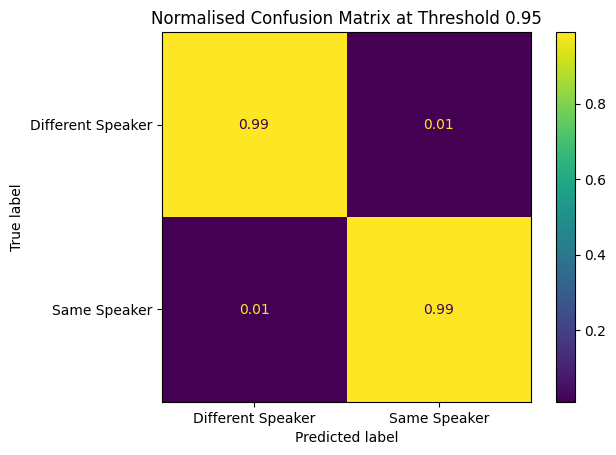

>> [OK] Confusion matrix saved to: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/normalised_confusion_matrix.png


In [42]:
# Create a normalised confusion matrix.
normalised_cm = confusion_matrix(
    y_true,
    y_pred,
    normalize="true"
)

# Display the normalised matrix.
disp = ConfusionMatrixDisplay(
    confusion_matrix=normalised_cm,
    display_labels=["Different Speaker", "Same Speaker"]
)

disp.plot(values_format=".2f")

plt.title(f"Normalised Confusion Matrix at Threshold {best_threshold:.2f}")

cm_norm_path = RESULTS_DIR / "normalised_confusion_matrix.png"
plt.savefig(cm_norm_path, dpi=300, bbox_inches="tight")

plt.show()

print(f">> [OK] Confusion matrix saved to: {cm_norm_path.resolve()}")

### 9.2 Evaluation Metrics

In [15]:
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
f1_score_value = 2 * (precision * recall) / (precision + recall)

print(f">> Accuracy: {accuracy:.3f}")
print(f">> Precision: {precision:.3f}")
print(f">> Recall: {recall:.3f}")
print(f">> Specificity: {specificity:.3f}")
print(f">> F1 Score: {f1_score_value:.3f}")

>> Accuracy: 0.986
>> Precision: 0.142
>> Recall: 0.990
>> Specificity: 0.986
>> F1 Score: 0.249


## 10. PCA and t-SNE Visualisation

In [ ]:
# Load saved speaker embeddings.
print(f">> [OK] Embeddings loaded from: {embedding_path.resolve()}")
print(f">> [INFO] Total embeddings: {len(embedding_df)}")
print(f">> [INFO] Total speakers: {embedding_df['speaker_id'].nunique()}")

>> [OK] Embeddings loaded from: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/speaker_embeddings.pkl
>> [INFO] Total embeddings: 855
>> [INFO] Total speakers: 284


In [22]:
# Select around 20 speakers.
selected_speakers = embedding_df["speaker_id"].unique()[:20]

# Keep only rows belonging to those speakers.
subset_df = embedding_df[embedding_df["speaker_id"].isin(selected_speakers)].copy()

print(f">> [OK] Selected speakers: {len(selected_speakers)}")
print(f">> [INFO] Selected embeddings: {len(subset_df)}")

>> [OK] Selected speakers: 20
>> [INFO] Selected embeddings: 60


In [23]:
# Stack all embeddings into one NumPy array.
X = np.stack(subset_df["embedding"].values)

# Speaker IDs will be used as labels in the plots.
speaker_labels = subset_df["speaker_id"].values

### 10.1. PCA Plot

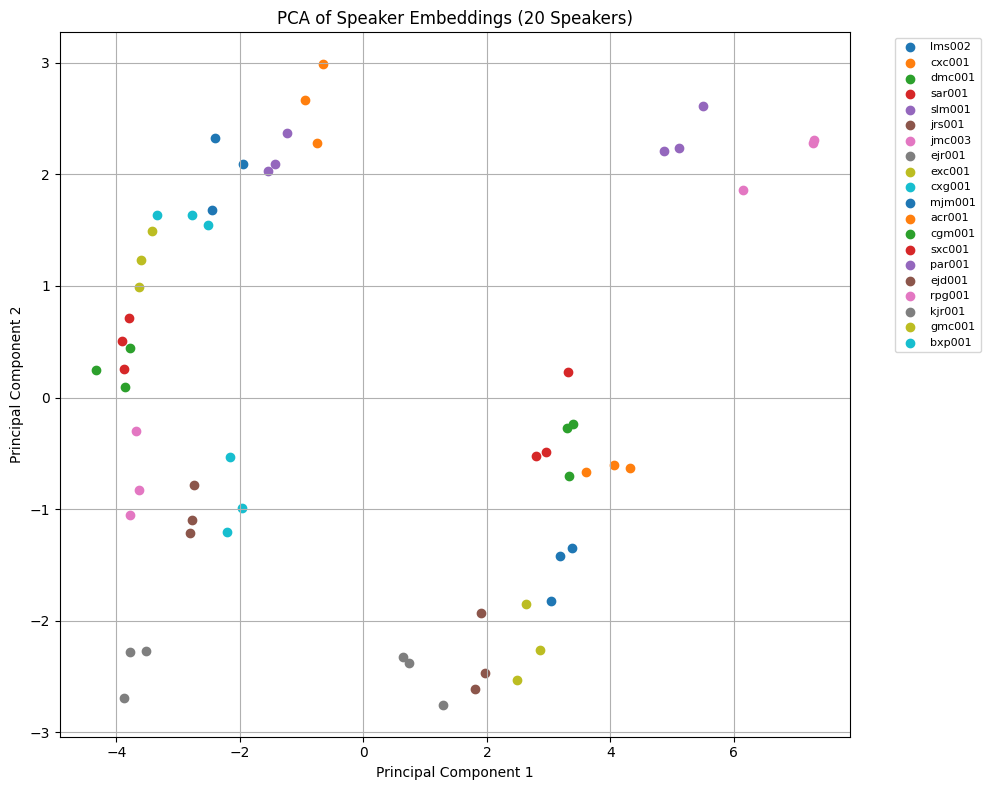

>> [OK] PCA plot saved to: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/pca_20_speakers.png


In [38]:
# Reduce embeddings to 2 dimensions using PCA.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create PCA plot.
plt.figure(figsize=(10, 8))

for speaker_id in selected_speakers:
    mask = speaker_labels == speaker_id
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=speaker_id
    )

plt.title("PCA of Speaker Embeddings (20 Speakers)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.grid()

pca_plot_path = RESULTS_DIR / "pca_20_speakers.png"
plt.savefig(pca_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print(f">> [OK] PCA plot saved to: {pca_plot_path.resolve()}")

### 10.2 t-SNE plot

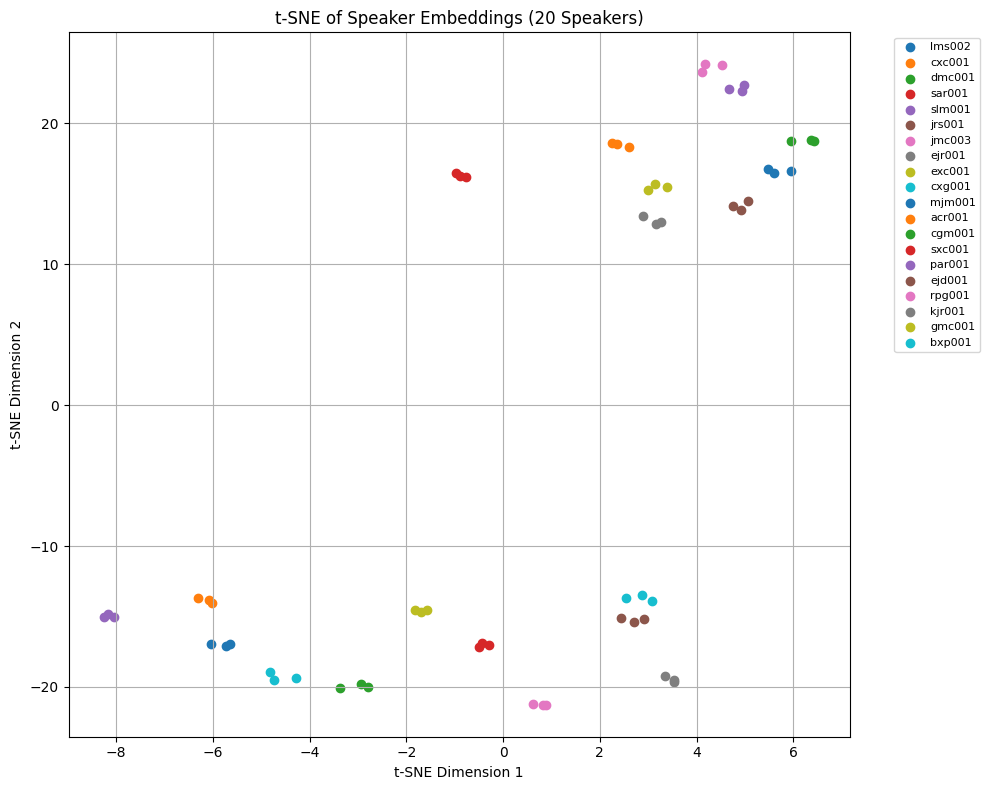

>> [OK] t-SNE plot saved to: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/tsne_20_speakers.png


In [ ]:
# Reduce embeddings to 2 dimensions using t-SNE.
# Perplexity 10 is reasonable here for a small subset.
tsne = TSNE(
    n_components=2,
    perplexity=10,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X)

# Create t-SNE plot.
plt.figure(figsize=(10, 8))

for speaker_id in selected_speakers:
    mask = speaker_labels == speaker_id
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        label=speaker_id
    )

plt.title("t-SNE of Speaker Embeddings (20 Speakers)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.grid()

tsne_plot_path = RESULTS_DIR / "tsne_20_speakers.png"
plt.savefig(tsne_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print(f">> [OK] t-SNE plot saved to: {tsne_plot_path.resolve()}")

## 11. End

In [30]:
elapsed_time = time.time() - start_time
print(f">> Elapsed Time: {elapsed_time:.3f} seconds | {elapsed_time / 60:.3f} minutes | {elapsed_time / 3600:.3f} hours")

>> Elapsed Time: 334.344 seconds | 5.572 minutes | 0.093 hours
